🚀 INITIALIZING COMMUNITYGUARD-AI: END-TO-END AUTOMATION (METRICS ENABLED)

[1/6] Booting CityLearn Digital Twin...
      -> Collecting Normal Baseline Operations...

[2/6] Training PyTorch Mathematical Defense Engine...

[3/6] Initializing 4-Node LangGraph Cyber-Physical Workflow...

[4/6] Executing Workflow & Simulating Mitigations...
      -> Resolving MARKET_HACK breach...
      -> Resolving METER_HACK breach...
      -> Resolving INVERTER_HACK breach...
      -> Resolving TIME_SPOOFING breach...

[5/6] Generating Verified Defense Reports...

🏆 INCIDENT REPORT: MARKET_HACK
 -> Llama 3 Diagnosis:  Market Hack
 -> Diagnosis Rationale: The high Mean Squared Error deviation in Pricing (3.8378) suggests a malicious attempt to manipulate the building's energy pricing, likely caused by an unauthorized entity attempting to disrupt the market dynamics.
 -> Llama 3 Protocol:   DIGITAL_TWIN_OVERRIDE
 -> Defense Strategy:   Implement immediate power cycling on Building 0's main electrical panel

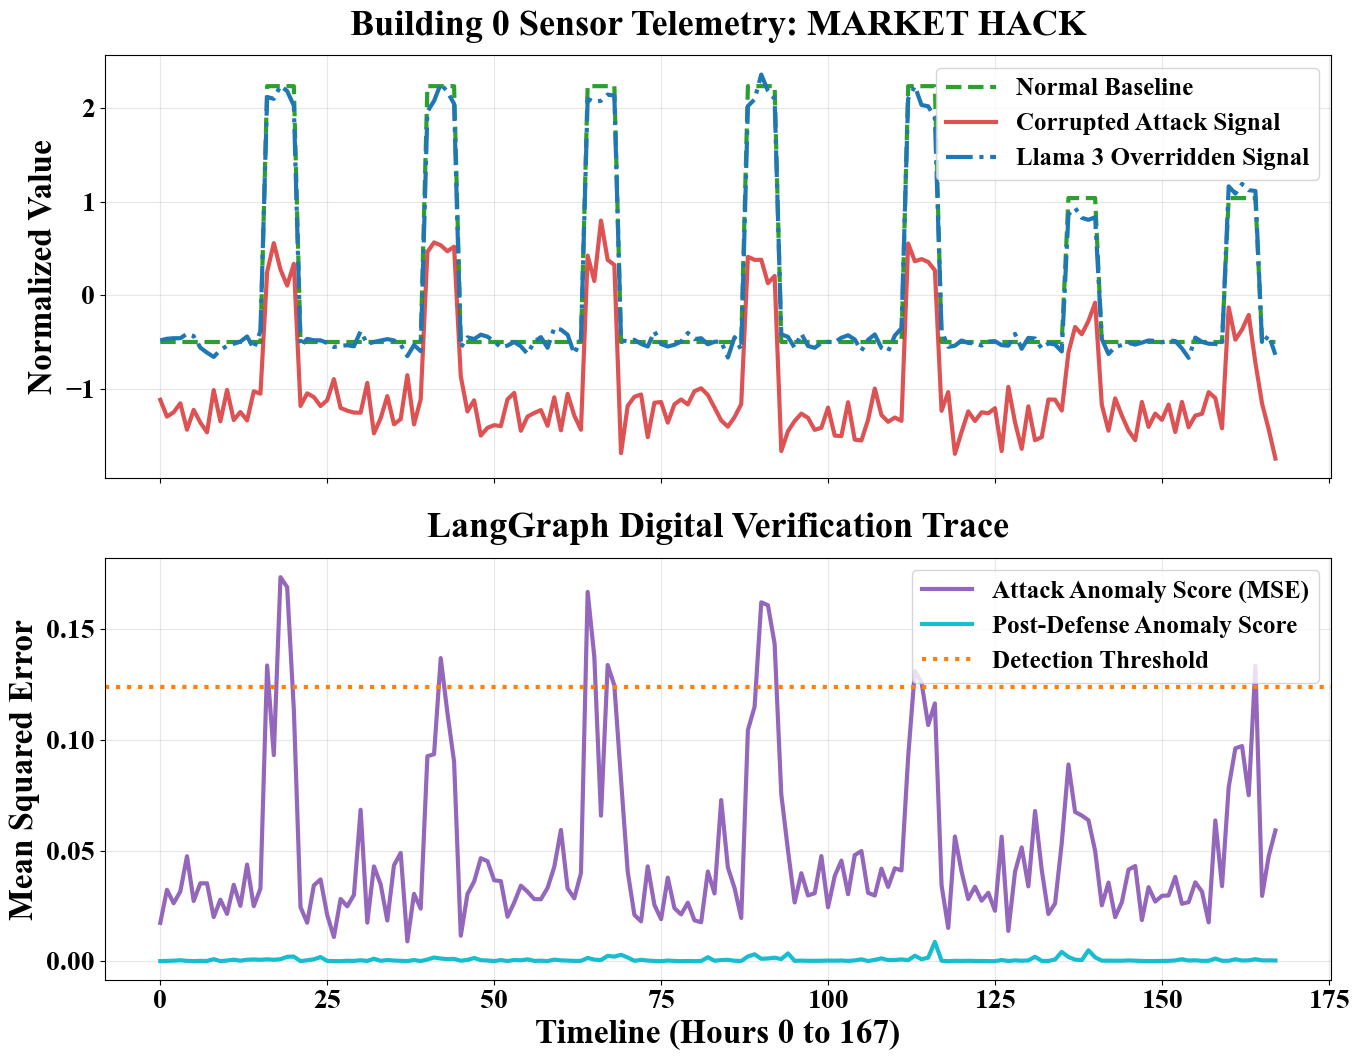


🏆 INCIDENT REPORT: METER_HACK
 -> Llama 3 Diagnosis:  Meter Hack
 -> Diagnosis Rationale: The Mean Squared Error deviation in Load Meter (2.0445) is significantly higher than the other sensors, indicating a potential tampering or manipulation of the load meter data, which is consistent with a Meter Hack attack.
 -> Llama 3 Protocol:   DIGITAL_TWIN_OVERRIDE
 -> Defense Strategy:   Implement immediate power cycling on Building 2's main electrical panel, followed by a manual re-synchronization of the building's energy metering system.
 -> Defense Rationale:  By overriding the digital twin and isolating the affected building's energy metering system, we can physically disconnect the hacked meter from the grid. This will prevent further manipulation of the energy profile and allow us to re-establish a stable baseline reading. The power cycling step ensures that any compromised firmware or software is reset, while the manual re-synchronization of the energy metering system allows us to veri

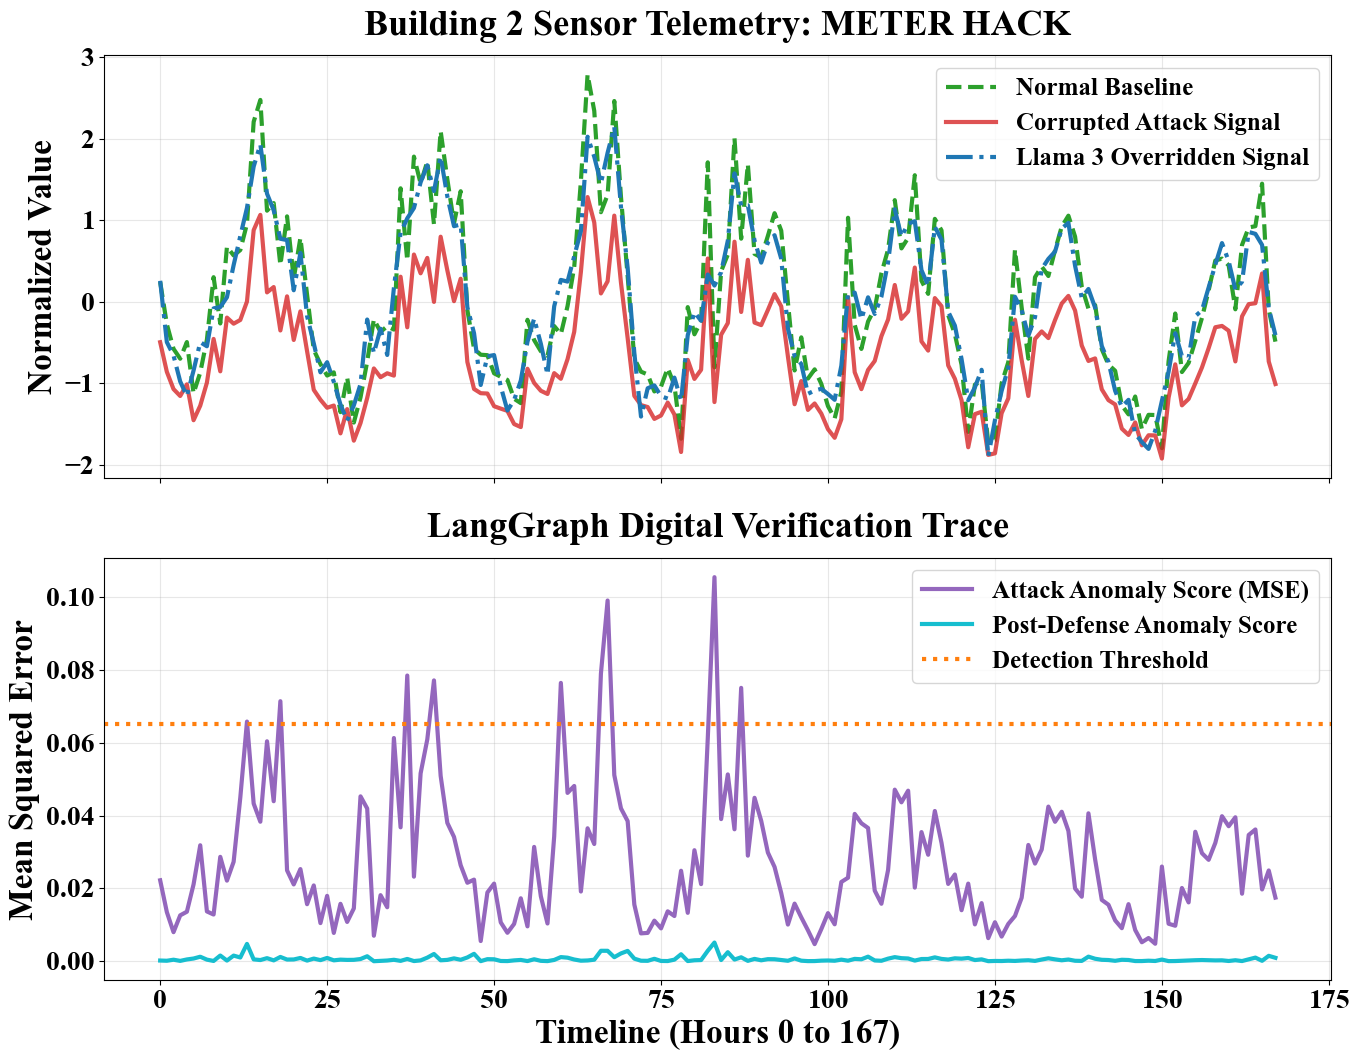


🏆 INCIDENT REPORT: INVERTER_HACK
 -> Llama 3 Diagnosis:  Inverter Hack
 -> Diagnosis Rationale: The high Mean Squared Error deviation (4.9771) in the Solar Inverter sensor suggests that an attacker has manipulated the inverter's output, likely to inject false data into the grid or disrupt the building's energy management system.
 -> Llama 3 Protocol:   DIGITAL_TWIN_OVERRIDE
 -> Defense Strategy:   Implement immediate power cycling on Building 2's main electrical panel, followed by a controlled re-energization sequence.
 -> Defense Rationale:  By overriding the digital twin of Building 2's energy management system with the actual physical state of the inverter hack, we can effectively 'reset' the cyber-physical anomaly. The power cycling will isolate the affected circuitry and prevent further propagation of the hack. The controlled re-energization sequence will then allow us to gradually restore power while monitoring for any residual anomalies, ensuring a stable energy profile is main

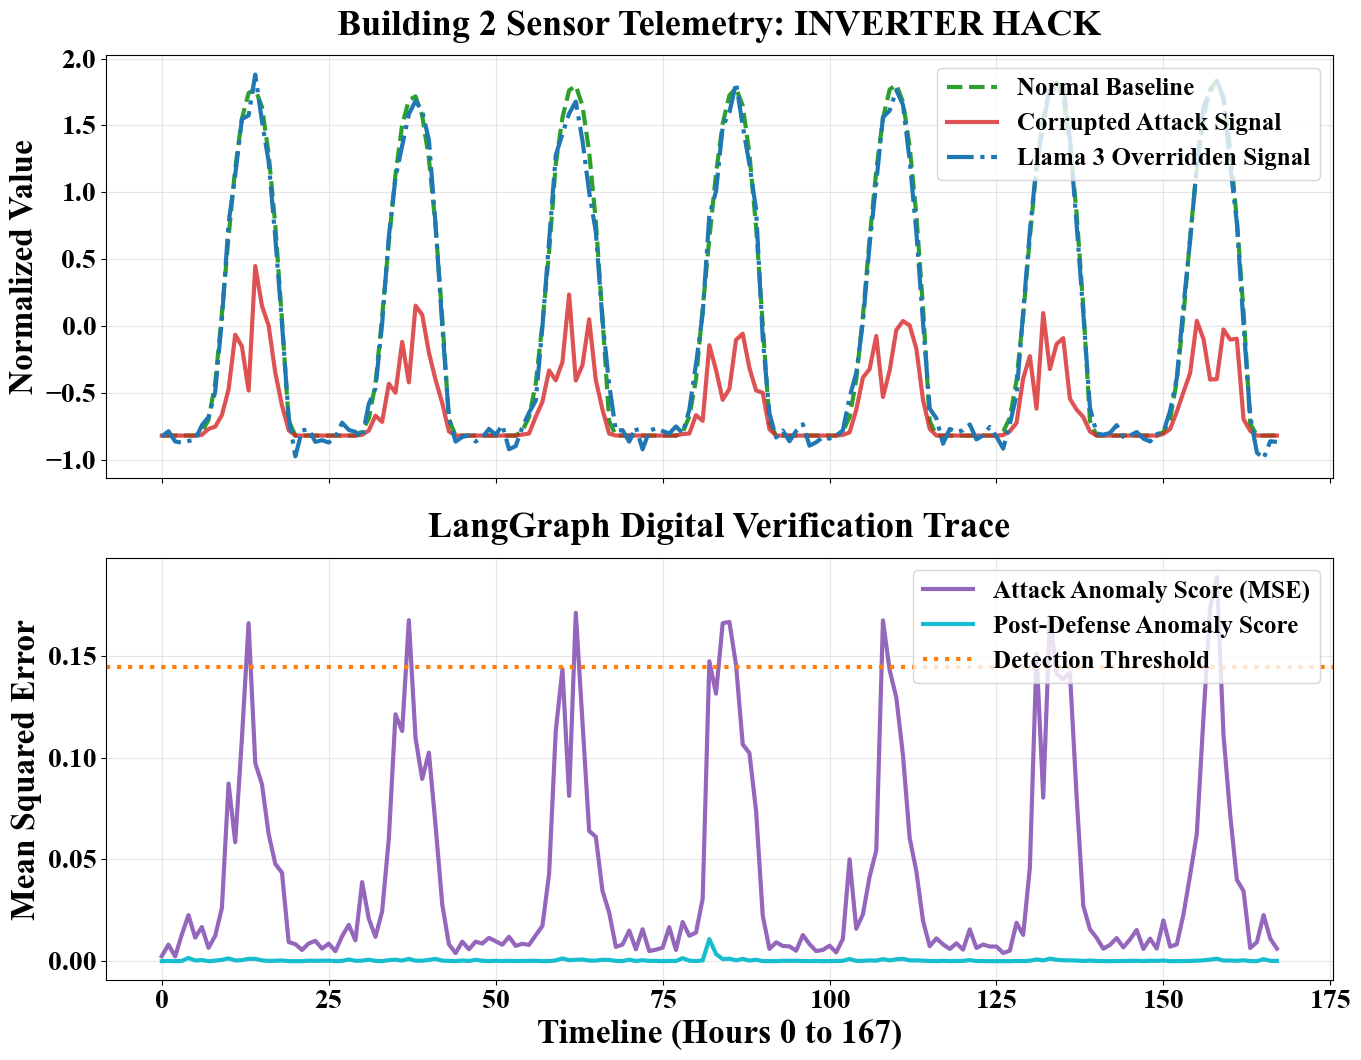


🏆 INCIDENT REPORT: TIME_SPOOFING
 -> Llama 3 Diagnosis:  Time Spoofing
 -> Diagnosis Rationale: The Clock Sync anomaly with a Mean Squared Error deviation of 8.7082 is significantly higher than the other sensors, indicating a potential time synchronization attack. This type of attack can be used to manipulate data and disrupt normal operations.
 -> Llama 3 Protocol:   DIGITAL_TWIN_OVERRIDE
 -> Defense Strategy:   Implement immediate power cycling on Building 1's main electrical panel, followed by a controlled re-energization sequence.
 -> Defense Rationale:  By overriding the digital twin of Building 1, we can temporarily disconnect the cyber-physical interface and prevent further manipulation. Power cycling the main electrical panel will physically reset the building's energy profile, effectively 'rewinding' the anomalous behavior caused by Time Spoofing. The controlled re-energization sequence ensures a stable and gradual reintroduction of power, allowing the community's energy grid

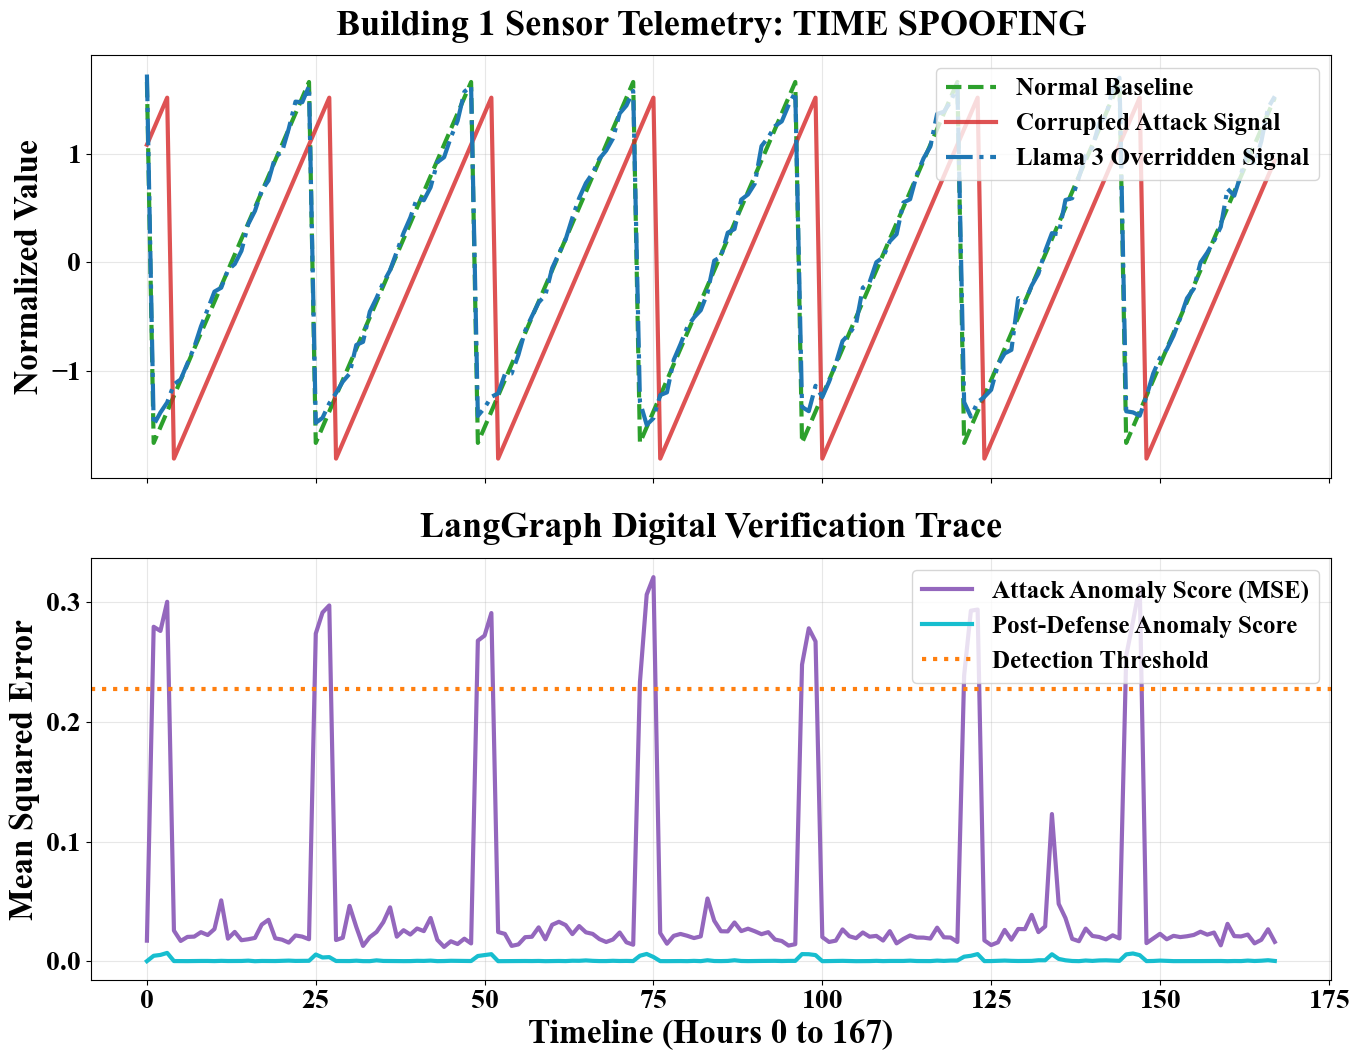


[6/6] Exporting Performance Metrics to CSV...
📊 Metrics successfully exported to: CommunityGuard_Performance_Metrics.csv
✅ Master Pipeline Complete. All agents executed successfully.


In [4]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import pandas as pd
from citylearn.citylearn import CityLearnEnv
from sklearn.preprocessing import StandardScaler
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Dict
from langchain_ollama import ChatOllama

print("="*70)
print("🚀 INITIALIZING COMMUNITYGUARD-AI: END-TO-END AUTOMATION (METRICS ENABLED)")
print("="*70)

# =====================================================================
# PART 1: THE DATA & MULTI-VECTOR ATTACK ARMORY (DETERMINISTIC)
# =====================================================================
print("\n[1/6] Booting CityLearn Digital Twin...")
env = CityLearnEnv(schema='citylearn_challenge_2022_phase_3')
num_buildings = len(env.observation_names)

obs_names = env.observation_names[0]
price_idx = obs_names.index('electricity_pricing')
load_idx = obs_names.index('non_shiftable_load')
solar_idx = obs_names.index('solar_generation')
time_idx = obs_names.index('hour') 

def collect_data(attack_vector="baseline", target_bldg=0):
    reset_result = env.reset()
    obs = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    history = []
    
    for step in range(168):
        if attack_vector == "market_hack":
            true_price = obs[target_bldg][price_idx]
            obs[target_bldg][price_idx] = (true_price * 0.60) + np.random.normal(0, 0.02)
        elif attack_vector == "meter_hack":
            true_load = obs[target_bldg][load_idx]
            obs[target_bldg][load_idx] = true_load * 0.70 
        elif attack_vector == "inverter_hack":
            true_solar = obs[target_bldg][solar_idx]
            obs[target_bldg][solar_idx] = true_solar * np.random.uniform(0.1, 0.5)
        elif attack_vector == "time_spoofing":
            obs[target_bldg][time_idx] = (obs[target_bldg][time_idx] - 4) % 24 
            
        history.append(np.concatenate(obs)) 
        
        # Zero Noise for precise diagnostics
        if isinstance(env.action_space, list):
            actions = [np.zeros(space.shape, dtype=np.float32) for space in env.action_space]
        else:
            actions = np.zeros(env.action_space.shape, dtype=np.float32)
            
        step_result = env.step(actions)
        obs = step_result[0]
        
    return np.array(history, dtype=np.float32)

print("      -> Collecting Normal Baseline Operations...")
raw_baseline = collect_data("baseline") 
scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(raw_baseline), dtype=torch.float32)

# =====================================================================
# PART 2: PYTORCH ANOMALY DETECTOR & THREAT MODELING
# =====================================================================
print("\n[2/6] Training PyTorch Mathematical Defense Engine...")
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64), nn.ReLU(), 
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 64), nn.ReLU(), 
    nn.Linear(64, X_train.shape[1])
)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss(reduction='none')

for _ in range(300):
    optimizer.zero_grad()
    loss = torch.mean(criterion(model(X_train), X_train))
    loss.backward()
    optimizer.step()
model.eval()

attack_vectors = ["market_hack", "meter_hack", "inverter_hack", "time_spoofing"]
attack_datasets = {}

for vector in attack_vectors:
    max_damage = -1.0
    worst_bldg = -1
    worst_dataset_tensor = None
    
    for bldg_id in range(num_buildings):
        raw_attack = collect_data(vector, bldg_id)
        attack_tensor = torch.tensor(scaler.transform(raw_attack), dtype=torch.float32)
        
        with torch.no_grad():
            reconstruction = model(attack_tensor)
            damage_score = torch.mean((reconstruction - attack_tensor)**2).item()
            
        if damage_score > max_damage:
            max_damage = damage_score
            worst_bldg = bldg_id
            worst_dataset_tensor = attack_tensor
            
    attack_datasets[vector] = worst_dataset_tensor

# =====================================================================
# PART 3: LANGGRAPH ORCHESTRATION (WITH METRICS)
# =====================================================================
print("\n[3/6] Initializing 4-Node LangGraph Cyber-Physical Workflow...")

class CommunityState(TypedDict):
    attack_name: str
    attack_tensor: torch.Tensor
    defended_tensor: torch.Tensor
    total_impact_kw: float
    detected_building_id: int            
    anomalous_sensors: Dict[str, float]  
    llama_diagnosis: str
    llama_reasoning: str
    llama_defense_command: str
    llama_defense_strategy: str       
    llama_defense_justification: str 
    verification_status: str
    post_defense_impact_kw: float
    forensics_latency: float
    forensics_tokens: int
    defense_latency: float
    defense_tokens: int

# NODE 1: PYTORCH DETECTION
def physics_impact_node(state: CommunityState):
    tensor = state["attack_tensor"]
    with torch.no_grad():
        reconstruction = model(tensor)
        total_mse = torch.mean((reconstruction - tensor)**2).item()
        
    total_features = X_train.shape[1]
    features_per_bldg = len(env.observation_names[0])
    
    true_3d = tensor.view(168, num_buildings, features_per_bldg)
    pred_3d = reconstruction.view(168, num_buildings, features_per_bldg)
    
    mse_matrix = torch.mean((true_3d - pred_3d)**2, dim=2).numpy()
    max_error_idx = np.unravel_index(np.argmax(mse_matrix), mse_matrix.shape)
    peak_hour, isolated_building = max_error_idx
    
    hour_peak_true = tensor[peak_hour]
    hour_peak_pred = reconstruction[peak_hour]
    feature_errors = ((hour_peak_true - hour_peak_pred)**2).numpy()
    
    start_idx = isolated_building * features_per_bldg
    sensor_errors = {
        "Electricity_Pricing": float(feature_errors[start_idx + price_idx]),
        "Non_Shiftable_Load": float(feature_errors[start_idx + load_idx]),
        "Solar_Generation": float(feature_errors[start_idx + solar_idx]),
        "Clock_Sync": float(feature_errors[start_idx + time_idx])
    }
    
    return {
        "total_impact_kw": total_mse * 15.5, 
        "detected_building_id": int(isolated_building),
        "anomalous_sensors": sensor_errors
    }

# NODE 2: FORENSICS AGENT
def forensics_node(state: CommunityState):
    sensors = state["anomalous_sensors"]
    bldg_id = state["detected_building_id"]
    
    prompt = f"""
    You are an AI Forensics Analyst. The community network shows an anomaly at Building {bldg_id}.
    Mean Squared Error deviations at peak impact:
    - Pricing: {sensors["Electricity_Pricing"]:.4f}
    - Load Meter: {sensors["Non_Shiftable_Load"]:.4f}
    - Solar Inverter: {sensors["Solar_Generation"]:.4f}
    - Clock Sync: {sensors["Clock_Sync"]:.4f}
    
    Respond ONLY in valid JSON format:
    {{
        "diagnosis": "Attack Name (e.g. Market Hack, Meter Hack, Time Spoofing, Inverter Hack)",
        "reasoning": "Why this specific sensor indicates this attack."
    }}
    """
    llm = ChatOllama(model="llama3", temperature=0.1)
    
    start_time = time.time()
    response = llm.invoke(prompt)
    latency = time.time() - start_time
    
    tokens = 0
    meta = response.response_metadata
    if meta:
        tokens = meta.get('prompt_eval_count', 0) + meta.get('eval_count', 0)

    try:
        content = response.content.strip()
        if content.startswith("```json"): content = content[7:]
        elif content.startswith("```"): content = content[3:]
        if content.endswith("```"): content = content[:-3]
        parsed = json.loads(content.strip())
    except:
        parsed = {"diagnosis": "Unknown", "reasoning": "Error parsing."}
        
    return {
        "llama_diagnosis": parsed.get("diagnosis", "Unknown"), 
        "llama_reasoning": parsed.get("reasoning", ""),
        "forensics_latency": latency,
        "forensics_tokens": tokens
    }

# NODE 3: DEFENSE AGENT
def defense_node(state: CommunityState):
    diagnosis = state["llama_diagnosis"]
    bldg_id = state["detected_building_id"]
    
    prompt = f"""
    You are the Community Defense Agent. The Forensics Node diagnosed a '{diagnosis}' on Building {bldg_id}.
    You must issue a defense command to stabilize the community's energy profile. 
    
    1. Select a technical protocol: "DIGITAL_TWIN_OVERRIDE" or "ASSET_ISOLATION".
    2. Define an actual physical defense strategy (e.g., 'Implement immediate power cycling on Building {bldg_id}s main electrical panel' or 'Isolate the power grid and re-route energy').
    3. Provide a 'justification' that gives a deep, technical reason explaining EXACTLY how this physical strategy and protocol will physically and electrically resolve the cyber-physical anomaly and restore grid stability.
    
    Respond ONLY in strictly valid JSON format exactly like this. Do not add markdown formatting or conversational text outside the JSON:
    {{
        "protocol": "The technical protocol name",
        "strategy": "The actionable physical strategy.",
        "justification": "The detailed technical reason why the strategy will work."
    }}
    """
    llm = ChatOllama(model="llama3", temperature=0.1)
    
    start_time = time.time()
    response = llm.invoke(prompt)
    latency = time.time() - start_time
    
    tokens = 0
    meta = response.response_metadata
    if meta:
        tokens = meta.get('prompt_eval_count', 0) + meta.get('eval_count', 0)

    try:
        content = response.content.strip()
        # Aggressive JSON cleaning
        if content.startswith("```json"): content = content[7:]
        elif content.startswith("```"): content = content[3:]
        if content.endswith("```"): content = content[:-3]
        parsed = json.loads(content.strip())
    except Exception as e:
        parsed = {
            "protocol": "DIGITAL_TWIN_OVERRIDE", 
            "strategy": f"Isolate compromised systems on Building {bldg_id}.",
            "justification": "Fallback protocol utilized due to system error."
        }
    
    # Catching multiple possible keys the LLM might hallucinate
    technical_justification = parsed.get("justification", parsed.get("reasoning", parsed.get("rationale", "No justification provided.")))
        
    return {
        "llama_defense_command": parsed.get("protocol", "DIGITAL_TWIN_OVERRIDE"),
        "llama_defense_strategy": parsed.get("strategy", "Isolate compromised systems."),
        "llama_defense_justification": technical_justification,
        "defense_latency": latency,
        "defense_tokens": tokens
    }

# NODE 4: PHYSICS VERIFICATION
def verification_node(state: CommunityState):
    attack_tensor = state["attack_tensor"].clone()
    bldg_id = state["detected_building_id"]
    command = state["llama_defense_command"]
    
    with torch.no_grad():
        safe_reconstruction = model(attack_tensor)
        
    total_features = X_train.shape[1]
    features_per_bldg = len(env.observation_names[0])
    start_col = bldg_id * features_per_bldg
    end_col = start_col + features_per_bldg
    
    defended_tensor = attack_tensor.clone()
    
    if "OVERRIDE" in command or "ISOLATION" in command:
        defended_tensor[:, start_col:end_col] = safe_reconstruction[:, start_col:end_col]
        
    with torch.no_grad():
        post_defense_reconstruction = model(defended_tensor)
        new_mse = torch.mean((post_defense_reconstruction - defended_tensor)**2).item()
        
    new_impact = new_mse * 15.5
    status = "VERIFIED SAFE" if new_impact < state["total_impact_kw"] else "VERIFICATION FAILED"
    
    return {
        "defended_tensor": defended_tensor,
        "post_defense_impact_kw": new_impact,
        "verification_status": status
    }

# Build the Graph
workflow = StateGraph(CommunityState)
workflow.add_node("detection", physics_impact_node)
workflow.add_node("forensics", forensics_node)
workflow.add_node("defense", defense_node)
workflow.add_node("verification", verification_node)

workflow.add_edge(START, "detection")
workflow.add_edge("detection", "forensics")
workflow.add_edge("forensics", "defense")
workflow.add_edge("defense", "verification")
workflow.add_edge("verification", END)
app = workflow.compile()

# =====================================================================
# PART 4: RUNNING THE AUTOMATION PIPELINE
# =====================================================================
print("\n[4/6] Executing Workflow & Simulating Mitigations...")
results_table = []
for attack_name, dataset in attack_datasets.items():
    print(f"      -> Resolving {attack_name.upper()} breach...")
    
    result = app.invoke({
        "attack_name": attack_name,
        "attack_tensor": dataset
    })
    results_table.append(result)

# =====================================================================
# PART 5: THE FINAL CYBER-PHYSICAL PLOTS (ATTACK VS DEFENSE)
# =====================================================================
print("\n[5/6] Generating Verified Defense Reports...")

# ---------------------------------------------------------------------
# LaTeX Formatting Configuration - Configures simulated LaTeX text and MASSIVE sizes
mpl.rcParams.update({
    "text.usetex": False,            # TURNED OFF to fix the Mac LaTeX Error
    "mathtext.fontset": "cm",        # Internally simulates the Computer Modern (LaTeX) font
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "font.size": 20,                 # Global size bump
    "font.weight": "bold",
    "axes.titlesize": 26,            # MASSIVE Title size
    "axes.titleweight": "bold",
    "axes.labelsize": 24,            # MASSIVE X/Y Axis Label size
    "axes.labelweight": "bold",
    "legend.fontsize": 18,           # Large Legend
    "xtick.labelsize": 20,           # MASSIVE X-Axis Numbers
    "ytick.labelsize": 20,           # MASSIVE Y-Axis Numbers
    "pdf.fonttype": 42,             
    "ps.fonttype": 42
})
# ---------------------------------------------------------------------

baseline_tensor = torch.tensor(scaler.transform(raw_baseline), dtype=torch.float32)
features_per_bldg = baseline_tensor.shape[1] // num_buildings

for result in results_table:
    vector_name = result["attack_name"]
    target_bldg = result["detected_building_id"]
    attack_tensor = result["attack_tensor"]
    defended_tensor = result["defended_tensor"]
    
    print(f"\n🏆 INCIDENT REPORT: {vector_name.upper()}")
    print(f" -> Llama 3 Diagnosis:  {result['llama_diagnosis']}")
    print(f" -> Diagnosis Rationale: {result['llama_reasoning']}")
    print(f" -> Llama 3 Protocol:   {result['llama_defense_command']}")
    print(f" -> Defense Strategy:   {result['llama_defense_strategy']}")
    print(f" -> Defense Rationale:  {result['llama_defense_justification']}") 
    print(f" -> Physics Status:     {result['verification_status']}")
    print(f" -> Pre-Defense Impact: {result['total_impact_kw']:.2f} kW")
    print(f" -> Post-Defense Impact:{result['post_defense_impact_kw']:.2f} kW")

    with torch.no_grad():
        pred_attack = model(attack_tensor)
        pred_defense = model(defended_tensor)

    true_attack_3d = attack_tensor.view(168, num_buildings, features_per_bldg)
    pred_attack_3d = pred_attack.view(168, num_buildings, features_per_bldg)
    true_defended_3d = defended_tensor.view(168, num_buildings, features_per_bldg)
    pred_defended_3d = pred_defense.view(168, num_buildings, features_per_bldg)

    mse_attack = torch.mean((true_attack_3d[:, target_bldg, :] - pred_attack_3d[:, target_bldg, :])**2, dim=1).numpy()
    mse_defended = torch.mean((true_defended_3d[:, target_bldg, :] - pred_defended_3d[:, target_bldg, :])**2, dim=1).numpy()

    feature_idx_map = {"market_hack": price_idx, "meter_hack": load_idx, "inverter_hack": solar_idx, "time_spoofing": time_idx}
    hacked_feature_idx = feature_idx_map.get(vector_name, load_idx)
    target_col = (target_bldg * features_per_bldg) + hacked_feature_idx

    vals_baseline = baseline_tensor[:, target_col].numpy()
    vals_attack = attack_tensor[:, target_col].numpy()
    vals_defended = defended_tensor[:, target_col].numpy()

    # Slightly increased figsize to accommodate massive fonts without overlapping
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    # Increased linewidths for better visibility
    ax1.plot(vals_baseline, label="Normal Baseline", color="#2ca02c", linestyle="--", linewidth=3)
    ax1.plot(vals_attack, label="Corrupted Attack Signal", color="#d62728", alpha=0.8, linewidth=3)
    ax1.plot(vals_defended, label="Llama 3 Overridden Signal", color="#1f77b4", linestyle="-.", linewidth=3)
    
    clean_title = vector_name.upper().replace("_", " ")
    ax1.set_title(f"Building {target_bldg} Sensor Telemetry: {clean_title}", fontweight='bold', pad=15)
    ax1.set_ylabel("Normalized Value", fontweight='bold')
    
    # Bold the legend text
    legend1 = ax1.legend(loc="upper right")
    for text in legend1.get_texts():
        text.set_weight("bold")
        
    ax1.grid(True, alpha=0.3)

    ax2.plot(mse_attack, label="Attack Anomaly Score (MSE)", color="#9467bd", linewidth=3)
    ax2.plot(mse_defended, label="Post-Defense Anomaly Score", color="#17becf", linewidth=3)
    
    threshold = np.mean(mse_attack) + 2*np.std(mse_attack)
    ax2.axhline(y=threshold, color="#ff7f0e", linestyle=":", linewidth=3, label="Detection Threshold")
    
    ax2.set_title("LangGraph Digital Verification Trace", fontweight='bold', pad=15)
    ax2.set_xlabel("Timeline (Hours 0 to 167)", fontweight='bold')
    ax2.set_ylabel("Mean Squared Error", fontweight='bold')
    
    # Bold the legend text
    legend2 = ax2.legend(loc="upper right")
    for text in legend2.get_texts():
        text.set_weight("bold")
        
    ax2.grid(True, alpha=0.3)

    # Ensure tick marks are bolded for ultimate clarity
    for ax in [ax1, ax2]:
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_weight("bold")

    plt.tight_layout()
    pdf_filename = f"CommunityGuard_Verified_Defense_{vector_name.upper()}.pdf"
    plt.savefig(pdf_filename, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# =====================================================================
# PART 6: METRICS AGGREGATION & CSV EXPORT
# =====================================================================
print("\n[6/6] Exporting Performance Metrics to CSV...")

metrics_data = []
for res in results_table:
    metrics_data.append({
        "Attack_Vector": res["attack_name"].upper(),
        "Target_Building": res["detected_building_id"],
        "Llama_Diagnosis": res["llama_diagnosis"],
        "Diagnosis_Rationale": res["llama_reasoning"],
        "Llama_Defense_Protocol": res["llama_defense_command"],
        "Llama_Defense_Strategy": res["llama_defense_strategy"],
        "Defense_Rationale": res["llama_defense_justification"],
        "Forensics_Latency_sec": round(res["forensics_latency"], 3),
        "Forensics_Tokens": res["forensics_tokens"],
        "Defense_Latency_sec": round(res["defense_latency"], 3),
        "Defense_Tokens": res["defense_tokens"],
        "Total_LLM_Latency_sec": round(res["forensics_latency"] + res["defense_latency"], 3),
        "Total_LLM_Tokens": res["forensics_tokens"] + res["defense_tokens"],
        "Pre_Defense_Impact_kW": round(res["total_impact_kw"], 2),
        "Post_Defense_Impact_kW": round(res["post_defense_impact_kw"], 2),
        "Verification_Status": res["verification_status"]
    })

# Convert to a Pandas DataFrame and export to CSV
df_metrics = pd.DataFrame(metrics_data)
csv_filename = "CommunityGuard_Performance_Metrics.csv"
df_metrics.to_csv(csv_filename, index=False)

print(f"📊 Metrics successfully exported to: {csv_filename}")
print("✅ Master Pipeline Complete. All agents executed successfully.")